In [94]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_style("whitegrid")

* **track_name**: Name of the song
* **artist(s)_name**: Name of the artist(s) of the song
* **artist_count**: Number of artists contributing to the song
* **released_year**: Year when the song was released
* **released_month**: Month when the song was released
* **released_day**: Day of the month when the song was released
* **in_spotify_playlists**: Number of Spotify playlists the song is included in
* **in_spotify_charts**: Presence and rank of the song on Spotify charts
* **streams**: Total number of streams on Spotify
* **in_apple_playlists**: Number of Apple Music playlists the song is included in
* **in_apple_charts**: Presence and rank of the song on Apple Music charts
* **in_deezer_playlists**: Number of Deezer playlists the song is included in
* **in_deezer_charts**: Presence and rank of the song on Deezer charts
* **in_shazam_charts**: Presence and rank of the song on Shazam charts
* **bpm**: Beats per minute, a measure of song tempo
* **key**: Key of the song
* **mode**: Mode of the song (major or minor)
* **danceability_%**: Percentage indicating how suitable the song is for dancing
* **valence_%**: Positivity of the song's musical content
* **energy_%**: Perceived energy level of the song
* **acousticness_%**: Amount of acoustic sound in the song
* **instrumentalness_%**: Amount of instrumental content in the song
* **liveness_%**: Presence of live performance elements
* **speechiness_%**: Amount of spoken words in the song

In [2]:
# https://www.kaggle.com/datasets/nelgiriyewithana/top-spotify-songs-2023
df = pd.read_csv("data/spotify-2023.csv", encoding="ISO-8859-2")

In [3]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
artist_count,953.0,1.556139,0.893044,1.0,1.0,1.0,2.0,8.0
released_year,953.0,2018.238195,11.116218,1930.0,2020.0,2022.0,2022.0,2023.0
released_month,953.0,6.033578,3.566435,1.0,3.0,6.0,9.0,12.0
released_day,953.0,13.930745,9.201949,1.0,6.0,13.0,22.0,31.0
in_spotify_playlists,953.0,5200.124869,7897.608990,31.0,875.0,2224.0,5542.0,52898.0
in_spotify_charts,953.0,12.009444,19.575992,0.0,0.0,3.0,16.0,147.0
in_apple_playlists,953.0,67.812172,86.441493,0.0,13.0,34.0,88.0,672.0
in_apple_charts,953.0,51.908709,50.630241,0.0,7.0,38.0,87.0,275.0
in_deezer_charts,953.0,2.666317,6.035599,0.0,0.0,0.0,2.0,58.0
bpm,953.0,122.540399,28.057802,65.0,100.0,121.0,140.0,206.0


### Numerical features

In [6]:
num_cols = list(df.select_dtypes(include="number").columns)

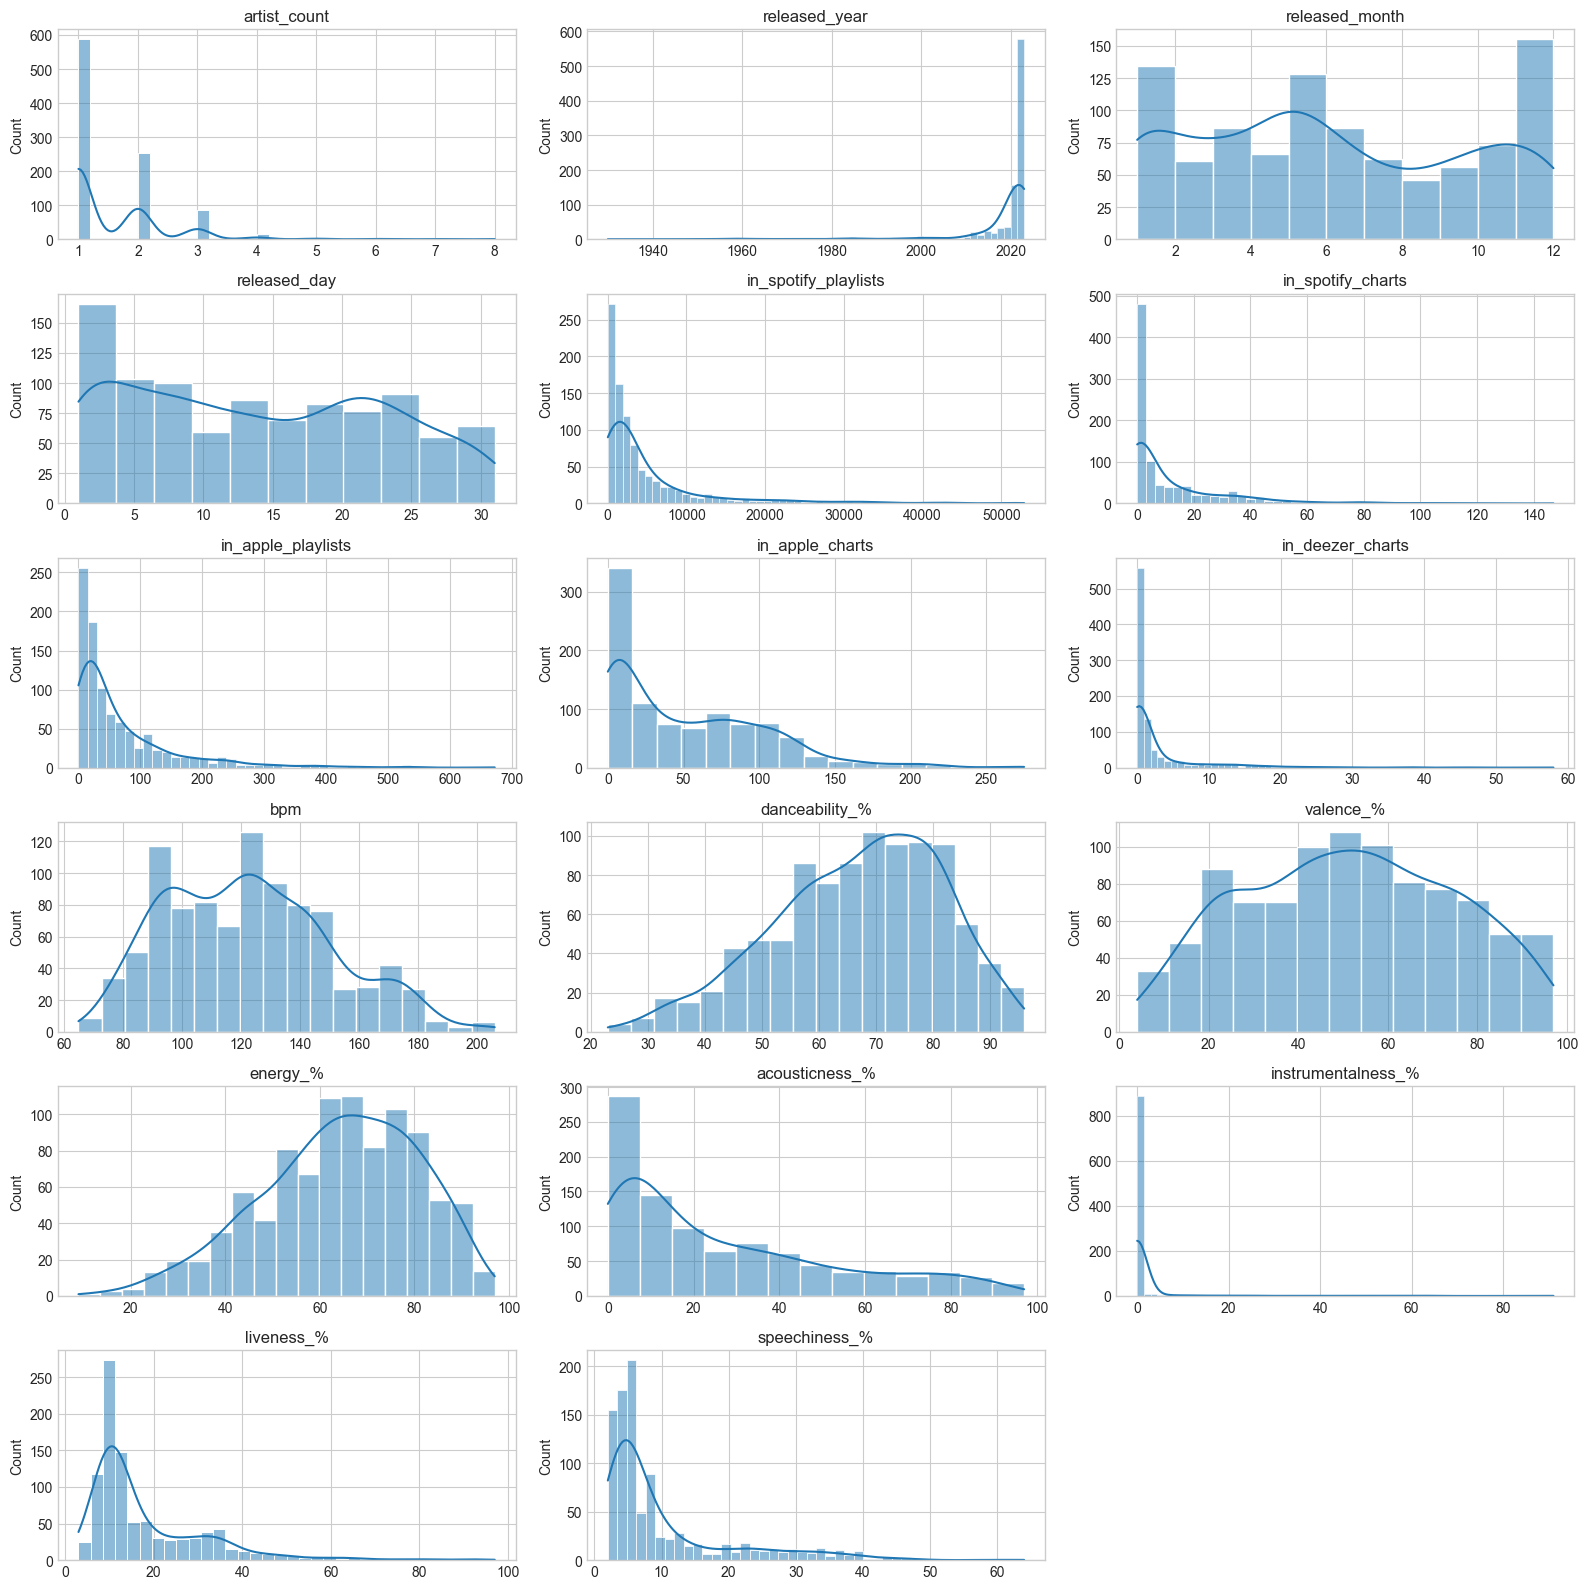

In [7]:
fig = plt.figure(figsize=(16, 16))
for i, col in enumerate(num_cols):
    ax = fig.add_subplot(6, 3, i + 1)
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

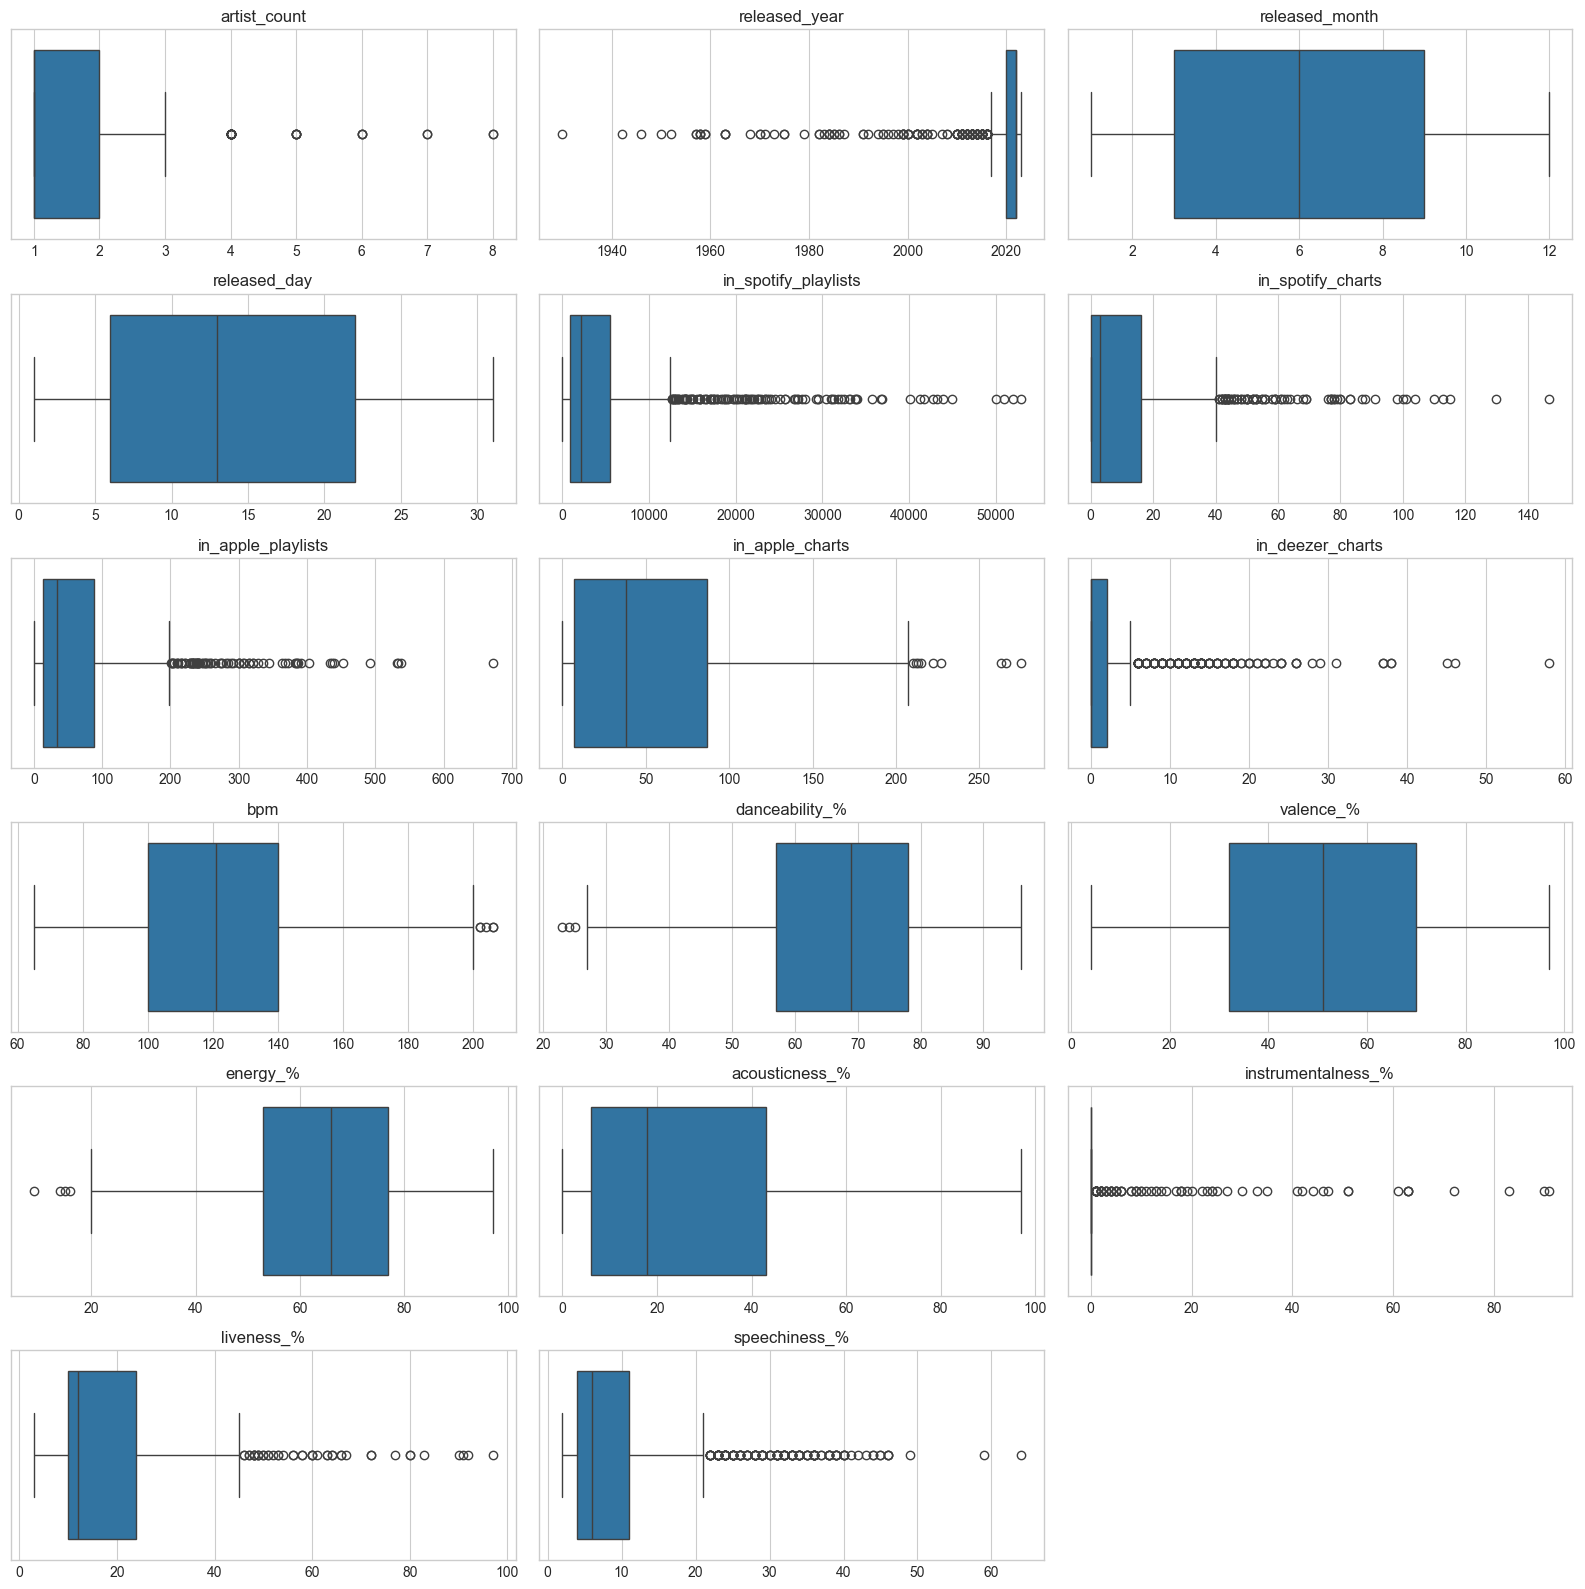

In [8]:
# There are many features with lots of outliers.
fig = plt.figure(figsize=(16, 16))
for i, col in enumerate(num_cols):
    ax = fig.add_subplot(6, 3, i + 1)
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [9]:
cat_cols = list(df.select_dtypes(include="object").columns)

In [10]:
cat_cols

['track_name',
 'artist(s)_name',
 'streams',
 'in_deezer_playlists',
 'in_shazam_charts',
 'key',
 'mode']

**streams**, **in_deezer_playlists**, **in_shazam_charts** features should be numeric. Need to analyze what row is causing that the whole column is being considered as object.

In [11]:
# Function to find indexes of rows where the column value is not numeric
def find_non_numeric_values(df: pd.DataFrame, cols: list[str]) -> dict[str, list[int]]:
    idx_dict = {}
    for col in cols:
        indexes = []
        for idx, row in df.iterrows():
            try:
                pd.to_numeric(row[col])
                continue
            except ValueError:
                indexes.append(idx)
        idx_dict[col] = indexes

    return idx_dict


non_num_dict = find_non_numeric_values(df, ["streams", "in_deezer_playlists", "in_shazam_charts"])
print(non_num_dict)

{'streams': [574], 'in_deezer_playlists': [48, 54, 55, 65, 73, 75, 80, 86, 88, 98, 103, 106, 109, 114, 126, 127, 128, 138, 140, 143, 147, 157, 162, 168, 172, 173, 176, 177, 179, 182, 188, 189, 199, 243, 250, 296, 297, 324, 325, 331, 358, 400, 403, 407, 440, 441, 442, 593, 604, 615, 620, 623, 624, 630, 634, 640, 641, 649, 653, 658, 668, 669, 672, 673, 685, 693, 697, 717, 720, 724, 725, 727, 754, 757, 761, 762, 871, 893, 910], 'in_shazam_charts': [12, 13, 17, 24, 44, 88, 89]}


In [12]:
# Display the actual values for those non-numeric rows
for col, indexes in non_num_dict.items():
    for idx in indexes:
        print(f"{col}[{idx}]: {df[col].iloc[idx]}")

streams[574]: BPM110KeyAModeMajorDanceability53Valence75Energy69Acousticness7Instrumentalness0Liveness17Speechiness3
in_deezer_playlists[48]: 2,445
in_deezer_playlists[54]: 3,394
in_deezer_playlists[55]: 3,421
in_deezer_playlists[65]: 4,053
in_deezer_playlists[73]: 1,056
in_deezer_playlists[75]: 4,095
in_deezer_playlists[80]: 1,003
in_deezer_playlists[86]: 1,800
in_deezer_playlists[88]: 2,703
in_deezer_playlists[98]: 1,632
in_deezer_playlists[103]: 2,394
in_deezer_playlists[106]: 1,034
in_deezer_playlists[109]: 2,163
in_deezer_playlists[114]: 2,655
in_deezer_playlists[126]: 6,551
in_deezer_playlists[127]: 1,212
in_deezer_playlists[128]: 1,078
in_deezer_playlists[138]: 2,094
in_deezer_playlists[140]: 2,969
in_deezer_playlists[143]: 3,889
in_deezer_playlists[147]: 5,239
in_deezer_playlists[157]: 3,394
in_deezer_playlists[162]: 3,631
in_deezer_playlists[168]: 4,607
in_deezer_playlists[172]: 2,733
in_deezer_playlists[173]: 3,425
in_deezer_playlists[176]: 1,378
in_deezer_playlists[177]: 1,0

In [13]:
# Many of the non-numeric values are float with a comma instead of a period -> Convert to number
# Only a value is a long string, probably a bad formating in the csv file -> delete the row
def convert_to_num(df: pd.DataFrame, mapping: dict[str, int]) -> pd.DataFrame:
    df = df.copy()
    error_indexes = set()
    for col, indexes in mapping.items():
        for idx in indexes:
            s = df[col].iloc[idx]
            if len(s) < 10: # if the string is shorter than 10 characters, it's probably a number'
                s = s.replace(",", ".")
                try:
                    n = pd.to_numeric(s)
                    # pd.to_numeric returns a numpy.float64 class
                    if isinstance(n, np.float64):
                        n = n.item() # access the value inside the numpy.float64 class
                    df.loc[idx, col] = n
                except ValueError as e:
                    error_indexes.add(idx)
            else:
                error_indexes.add(idx)

    if error_indexes:
        df = df.drop(index=error_indexes)
        print(f"Deleted indexes: {list(error_indexes)}")

    return df

df = convert_to_num(df, non_num_dict)

Deleted indexes: [574]


In [14]:
# Set the modified columns as numeric:
df["streams"] = df["streams"].astype(int)
df["in_deezer_playlists"] = df["in_deezer_playlists"].astype(float)
df["in_shazam_charts"] = df["in_shazam_charts"].astype(float)

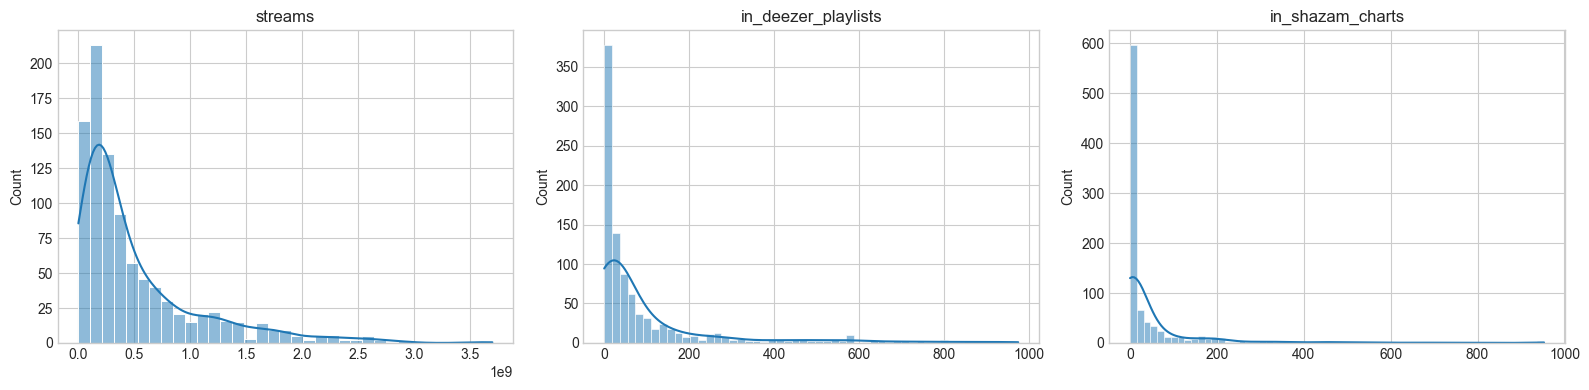

In [15]:
# Plot the histogram and boxplot:
new_num_cols = ["streams", "in_deezer_playlists", "in_shazam_charts"]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
axs = axs.flatten()
for i, col in enumerate(new_num_cols):
    sns.histplot(df[col], kde=True, ax=axs[i])
    axs[i].set_title(col)
    axs[i].set_xlabel("")
plt.tight_layout()
plt.show()

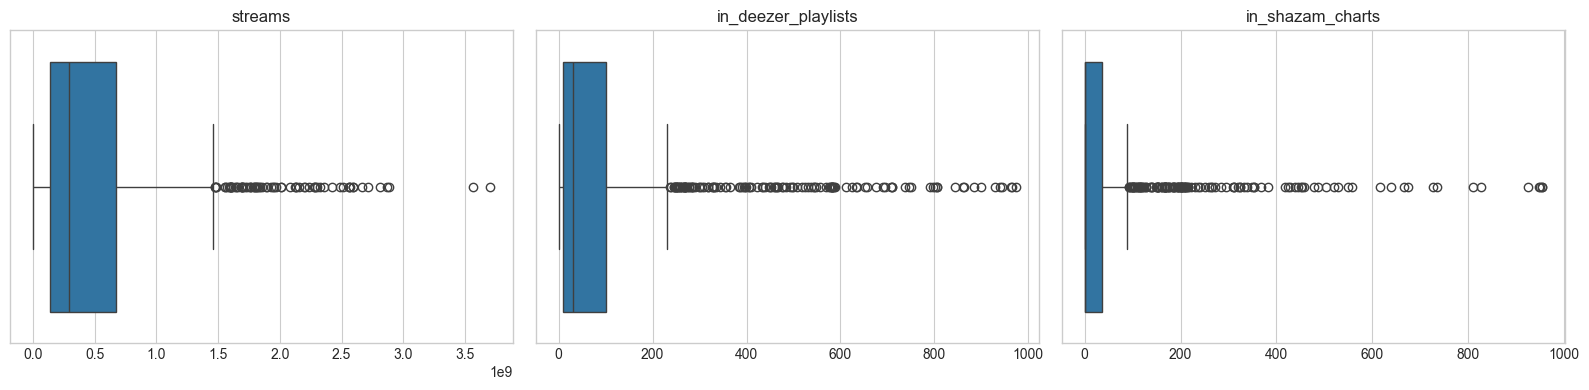

In [16]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
axs = axs.flatten()
for i, col in enumerate(new_num_cols):
    sns.boxplot(x=df[col], ax=axs[i])
    axs[i].set_title(col)
    axs[i].set_xlabel("")
plt.tight_layout()
plt.show()

### Categorical features

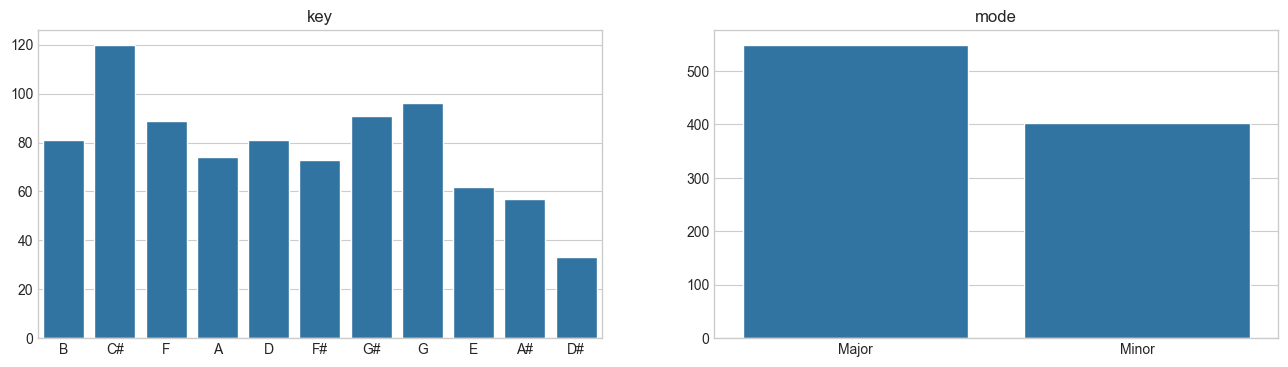

In [17]:
# Skip the song and artist names columns for visualization
new_cat_cols = ["key", "mode"]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))
axs = axs.flatten()
for i, col in enumerate(new_cat_cols):
    sns.countplot(x=col, data=df, ax=axs[i])
    axs[i].set_title(col)
    axs[i].set_xlabel("")
    axs[i].set_ylabel("")
plt.show()

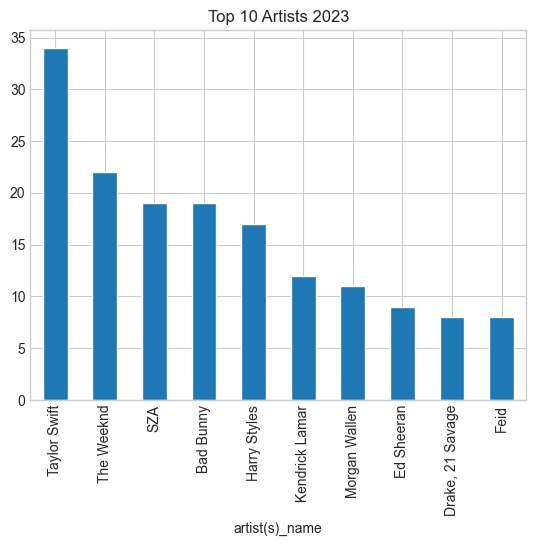

In [18]:
df["artist(s)_name"].value_counts().head(10).plot(kind="bar", title="Top 10 Artists 2023")
plt.show()

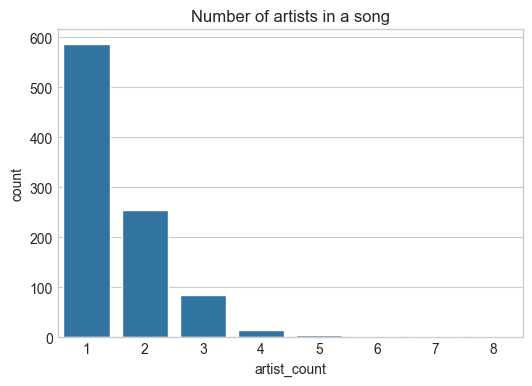

In [108]:
# There are many songs with more than 1 artist:
plt.figure(figsize=(6, 4))
ax = sns.countplot(df, x="artist_count")
ax.set_title("Number of artists in a song")
plt.show()

In [19]:
# There are many songs with more than 1 artist:
df.loc[df["artist_count"] > 1].head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
5,Sprinter,"Dave, Central Cee",2,2023,6,1,2186,91,183706234,67,...,141,C#,Major,92,66,58,19,0,8,24
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,34,...,148,F,Minor,67,83,76,48,0,8,3
9,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2,2023,3,17,2953,44,553634067,49,...,170,D,Minor,81,56,48,21,0,8,33
10,un x100to,"Bad Bunny, Grupo Frontera",2,2023,4,17,2876,40,505671438,41,...,83,F#,Minor,57,56,72,23,0,27,5


In [109]:
df["artist(s)_name"].apply(lambda x: x.split(","))

0         [Latto,  Jung Kook]
1               [Myke Towers]
2            [Olivia Rodrigo]
3              [Taylor Swift]
4                 [Bad Bunny]
                ...          
948            [Selena Gomez]
949            [Taylor Swift]
950     [Feid,  Paulo Londra]
951    [Feid,  Sech,  Jhayco]
952               [Burna Boy]
Name: artist(s)_name, Length: 952, dtype: object

### Correlation matrix

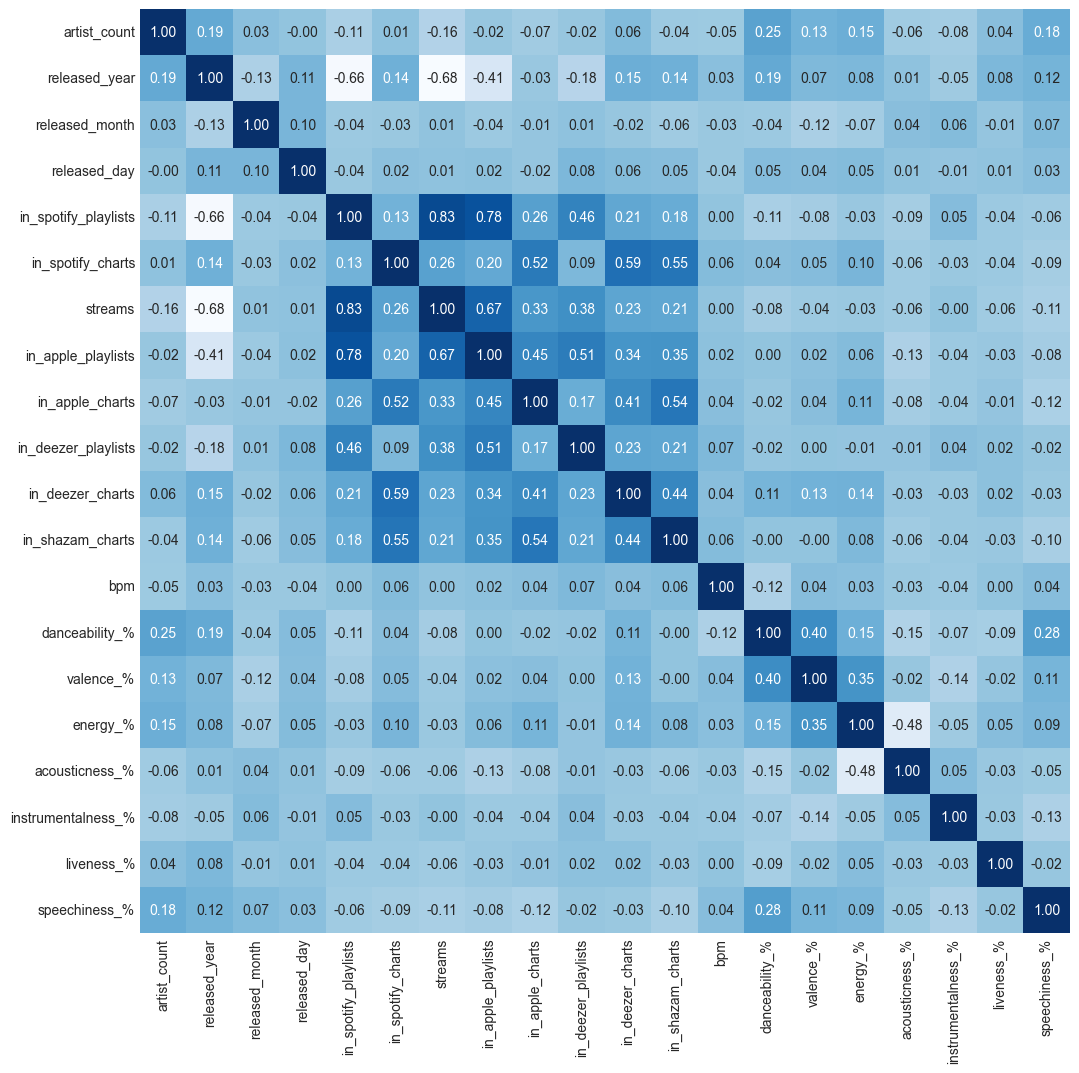

In [76]:
df.corr(method="spearman", numeric_only=True)
fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(df.corr(method="spearman", numeric_only=True), annot=True, fmt=".2f", ax=ax, cbar=False, cmap="Blues")
plt.show()

### Relation between features

In [100]:
# Top 100 most streamed songs with average features
(df.sort_values(by="streams", ascending=False)[["bpm", "danceability_%", "valence_%", "energy_%", "acousticness_%",
                                               "instrumentalness_%", "liveness_%", "speechiness_%"]]
 .head(100).mean(skipna=True))

bpm                   122.60
danceability_%         62.99
valence_%              50.84
energy_%               64.67
acousticness_%         26.46
instrumentalness_%      0.43
liveness_%             17.35
speechiness_%           7.68
dtype: float64

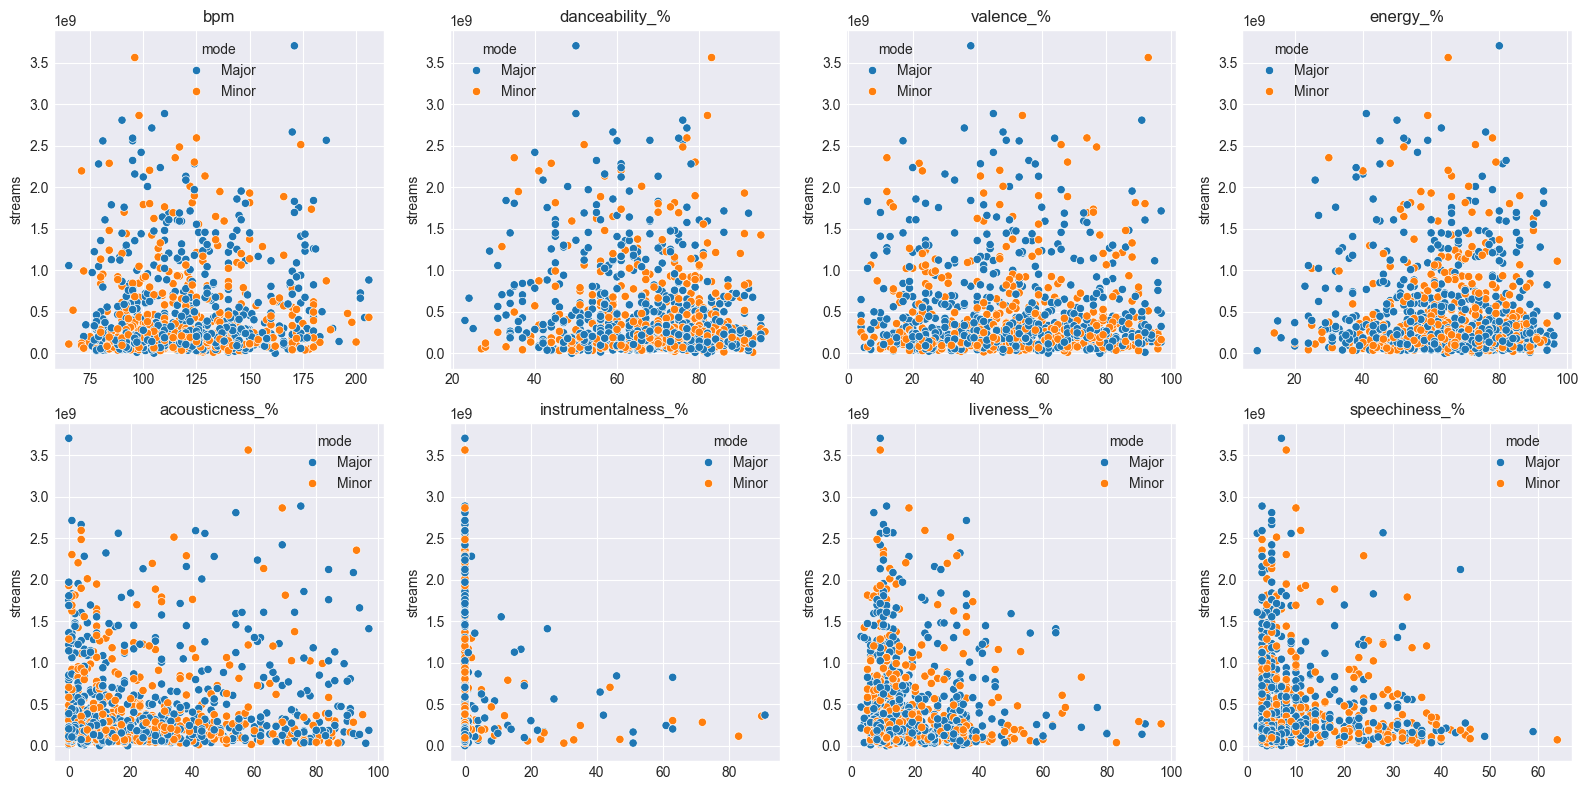

In [35]:
num_feat = [
    "bpm", "danceability_%", "valence_%", "energy_%", "acousticness_%",
    "instrumentalness_%", "liveness_%", "speechiness_%"
]

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axs = axs.flatten()
for i, feat in enumerate(num_feat):
    sns.scatterplot(data=df, x=feat, y="streams", ax=axs[i], hue="mode")
    axs[i].set_title(feat)
    axs[i].set_xlabel("")
plt.tight_layout()
plt.show()

Songs with low values of instrumentalness, liveness and speechiness tend to have more streams. While for the other scorable features have an ideal range.

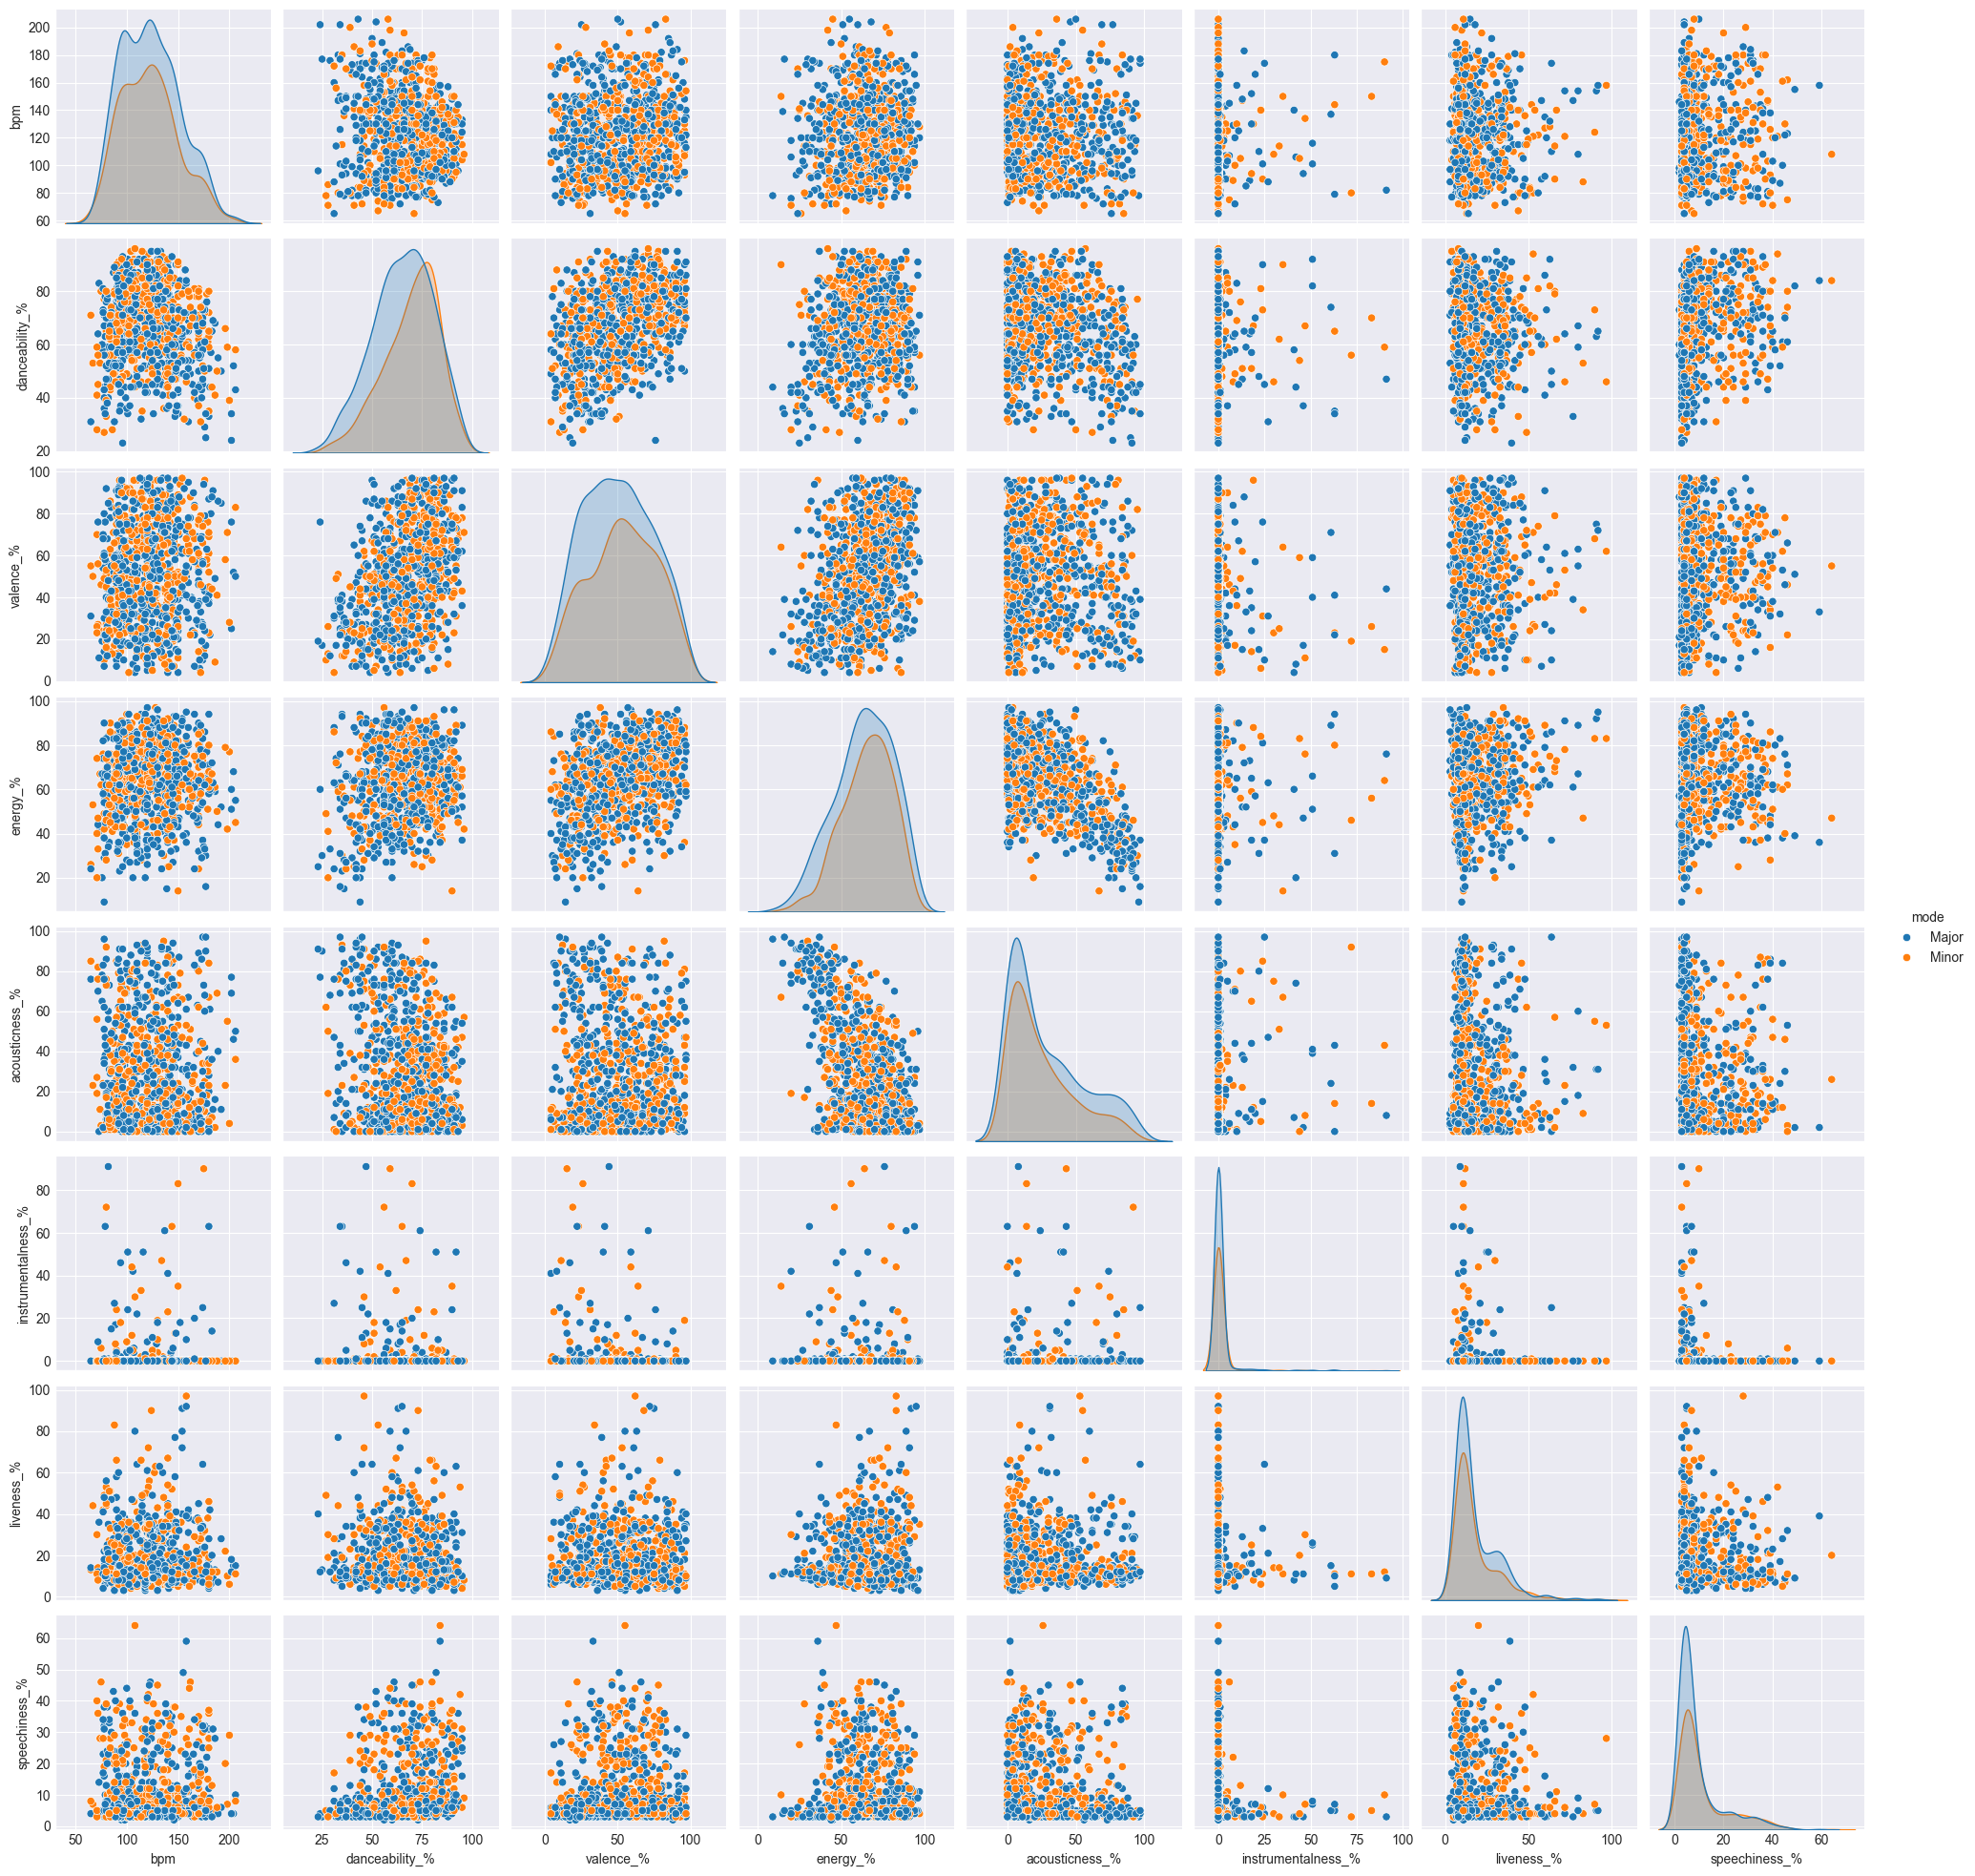

In [36]:
# It seems that the scorable features (danceability, energy, etc.) aren't correlated with themselves
pgrid = sns.pairplot(data=df, vars=num_feat, hue="mode", diag_kind="kde")
plt.show()

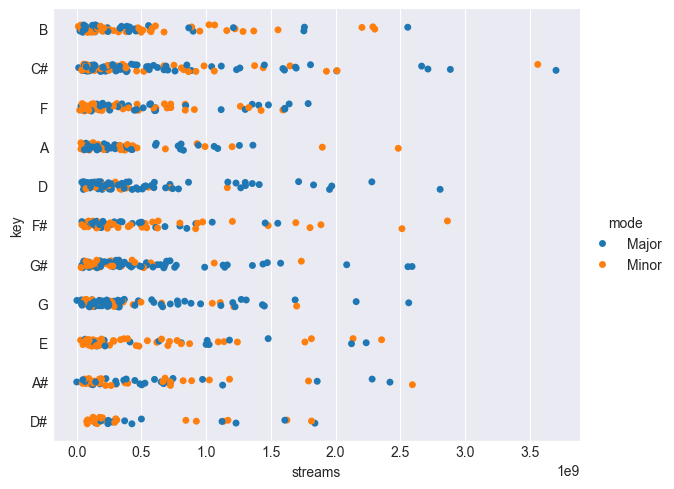

In [44]:
# Key feature seems to be correlated with streams.
sns.catplot(data=df, y="key", x="streams", kind="strip", hue="mode", aspect=1.2)
plt.show()

In [49]:
# Create a new column with the date of release in the format YYYY/MM/DD:
release_date = df["released_year"].astype(str) + "/" + df["released_month"].astype(str) + "/" + df["released_day"].astype(str)
df["release_date"] = pd.to_datetime(release_date, yearfirst=True)

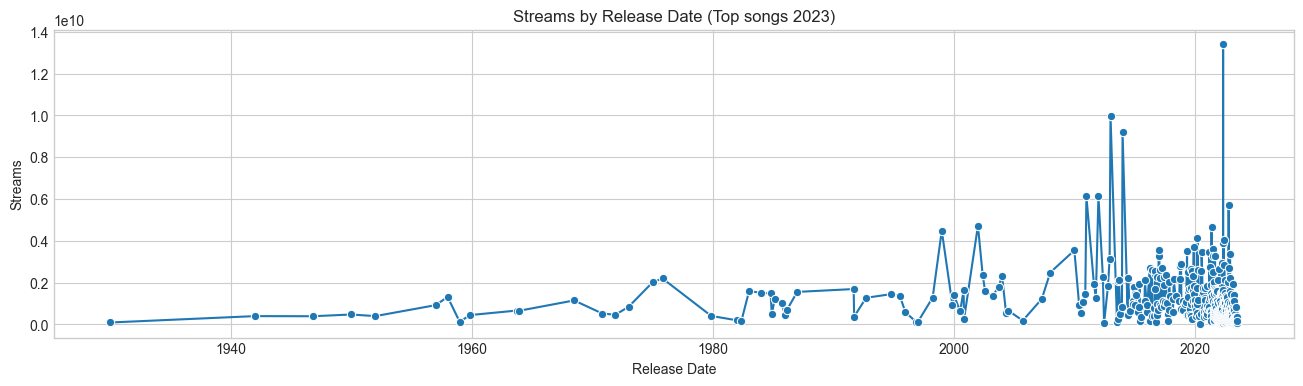

In [103]:
fig, ax = plt.subplots(figsize=(16, 4))
streams_by_release_date = df.groupby("release_date")["streams"].sum().sort_index(ascending=True)
sns.lineplot(data=streams_by_release_date, marker="o", ax=ax)
ax.set_title("Streams by Release Date (Top songs 2023)")
ax.set_xlabel("Release Date")
ax.set_ylabel("Streams")
plt.show()

In [69]:
# There were songs from older decades in the top 10 of 2023. No one song from 2023 in the top 10.
streams_by_release_date.sort_values(ascending=False).head(10)

release_date
2022-05-06    13432412789
2013-01-01     9971940841
2014-01-01     9188569535
2011-01-01     6125872350
2012-01-01     6118305522
2022-10-21     5695886046
2002-01-01     4720379660
2021-05-21     4674584179
1999-01-01     4484162421
2020-03-20     4114837169
Name: streams, dtype: int64

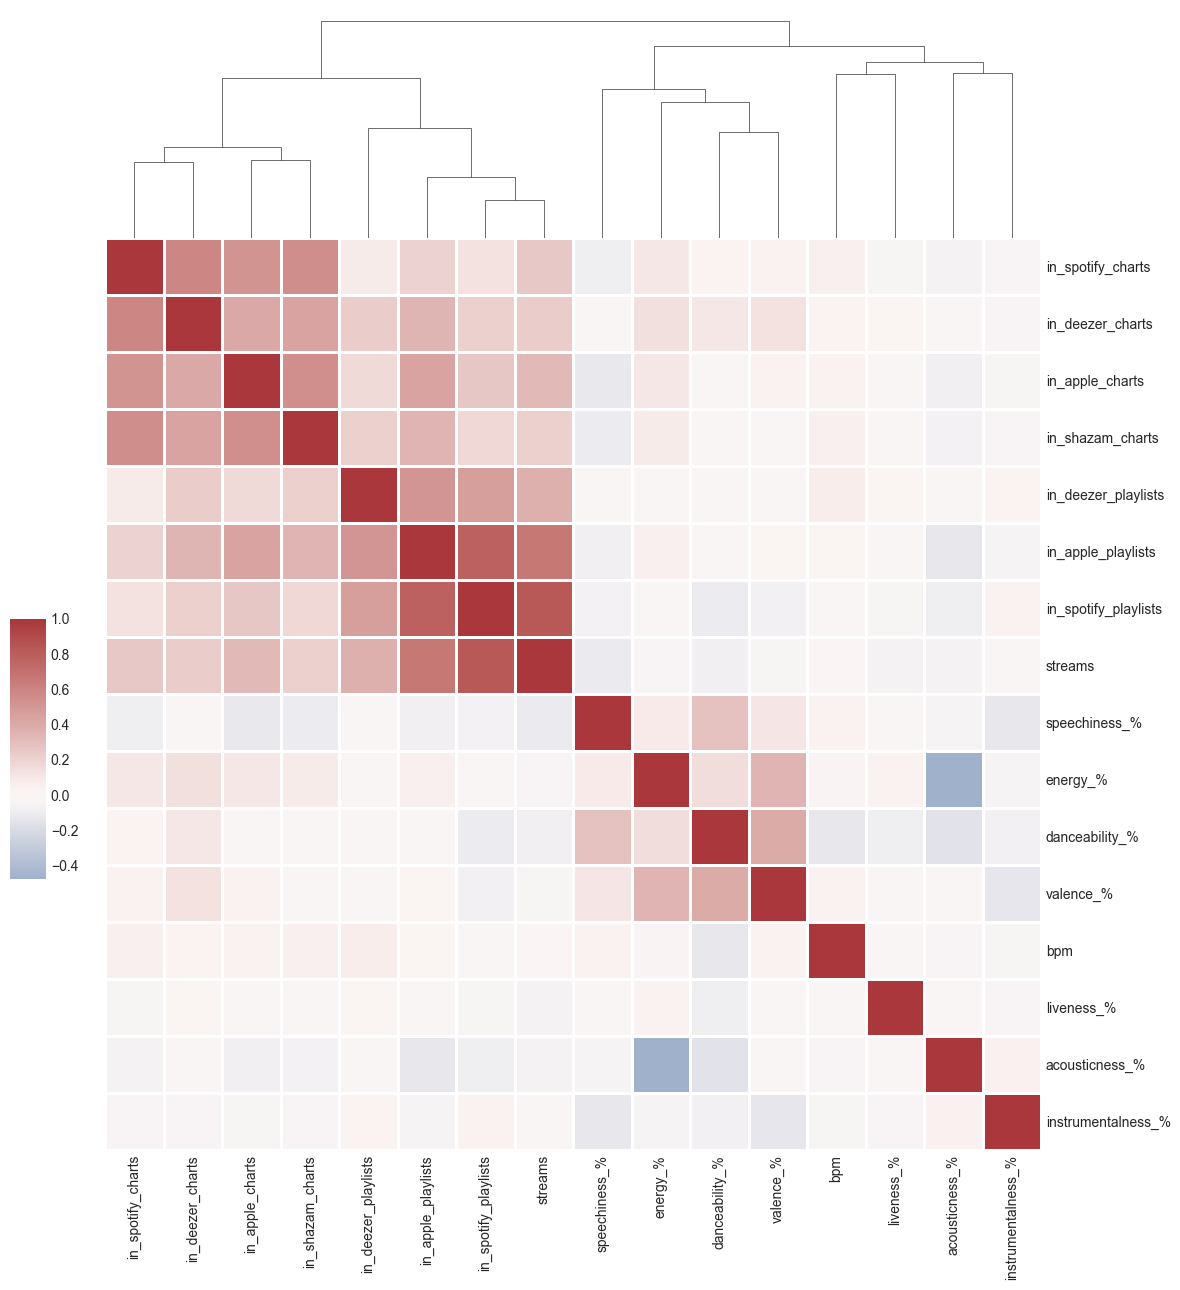

In [102]:
# Another correlation matrix with a dendrogram, it groups the scorable features (danceability, energy, etc.) together in the same group and the number of playlists and duration in the charts in another group. Which makes sense.
g = sns.clustermap(df.drop(
    ["released_year", "released_month", "released_day", "artist_count"],
    axis=1).corr(
    numeric_only=True, method="spearman"
), center=0, cmap="vlag",
    dendrogram_ratio=(.1, .2),
    cbar_pos=(.02, .32, .03, .2),
    linewidths=.75, figsize=(12, 13))
g.ax_row_dendrogram.remove()

In [96]:
# Scale the streams column to a range between 0 and 1, just for visualization purposes:
df_scaled = df.copy()
stream_scaler = MinMaxScaler()
df_scaled["streams"] = stream_scaler.fit_transform(df["streams"].values.reshape(-1, 1))

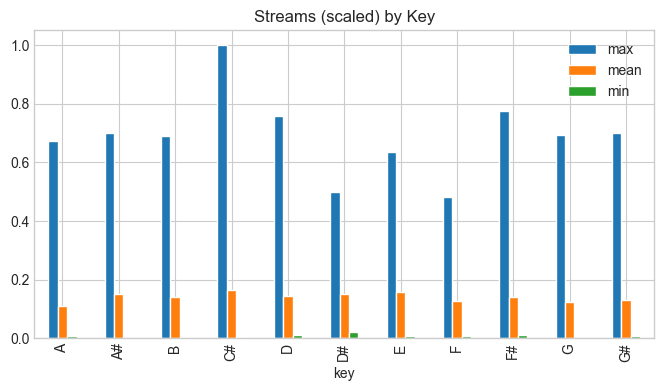

In [99]:
# Songs with sharp (#) keys tend to have more streams. C# has to top.
fig, ax = plt.subplots(figsize=(8, 4))
keys_df = df_scaled.groupby("key")["streams"].agg(["max", "mean", "min"])
keys_df.plot(kind="bar", ax=ax)
ax.set_title("Streams (scaled) by Key")
plt.show()

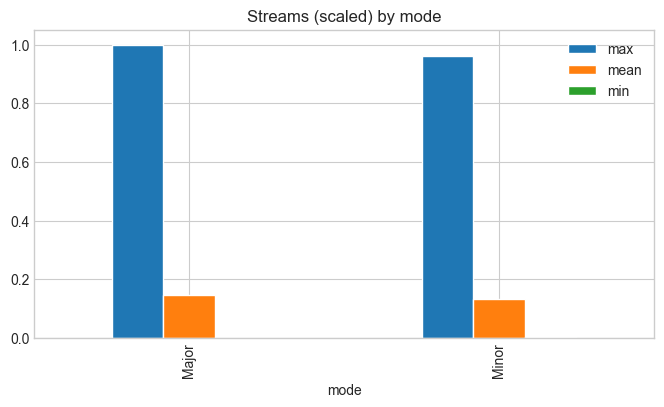

In [105]:
# Songs with major mode tend to have more streams, but the difference is not that big.
fig, ax = plt.subplots(figsize=(8, 4))
keys_df = df_scaled.groupby("mode")["streams"].agg(["max", "mean", "min"])
keys_df.plot(kind="bar", ax=ax)
ax.set_title("Streams (scaled) by mode")
plt.show()